# Jupyer Notebook for Controlling  Stepper Motors Linear rail with an Arduino with Integrated UV-Vis measurements using a HR2000+ Spectrometer


 Version 2.1 JULY 2023

YuCheng, Imperial College London (Adapted from Niall M)

Controlling 1 stepper motors with integrated measurements

# Imports for seabreeze (spectrometer), serial (motor) and standard libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import time
from time import perf_counter
import serial
import serial.tools.list_ports
from serial import Serial
from IPython import display
from scipy.optimize import curve_fit 
from scipy import interpolate
from pylab import *
from math import *
from datetime import datetime
import seabreeze.spectrometers as sb
#import seabreeze.pyseabreeze as psb
import seabreeze.cseabreeze as csb
### os
import os
###import custom functions / class
import SpectrometerMultiplexerFunctions as SMF
### astropy signal processing
from astropy.convolution import convolve, Box1DKernel

from pathlib import Path

# Make an object called spec from the Spectrometer Class

In [2]:
#plot the data
def plotting_spectra (wavelengths, intensities, smoothbool, smoothfactor, color,xlim1,xlim2,ylim1,ylim2):
    fig,ax = plt.subplots()
    if smoothbool == True:
        intensities = convolve(intensities, Box1DKernel(smoothfactor))
    ax.plot(wavelengths, intensities, color = color)
    plt.ylabel('Intensity (a.u)')
    plt.xlabel('Wavelength (nm)')
    ax.yaxis.grid(True)
    ax.tick_params(axis = 'x',rotation=45)
    ax.xaxis.tick_bottom()
    if xlim2 >1:
        plt.xlim(xlim1,xlim2)
    if ylim2 >1:
        plt.ylim(ylim1,ylim2)
    plt.show()
    return wavelengths,intensities
    

In [3]:
## Normalise and reduce data
def normalizeAndReduce(wavelength, intensity, lower_bin, upper_bin):
    count1 = 0
    count2 = 0
    sumwave1 = 0
    sumwave2 = 0
    
    # enumerate data - lower bin first 
    for i, val in enumerate(wavelength):
        if val >= lower_bin[0] and val <= lower_bin[1]:
            sumwave1 +=  intensity[i]
            count1 += 1
    # enumerate data - upper bin second 
    if upper_bin == (0,0):
        return (sumwave1 / count1)
    else: 
        for i, val in enumerate(wavelength):
            if val >= upper_bin[0] and val <= upper_bin[1]:
                sumwave2 = sumwave2 + intensity[i]
                count2 += 1
        return ((sumwave1 / count1) / (sumwave2 / count2)) * 100
    


In [4]:
def monitorfunction(position,spec, totaltime,recordstep,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2):
    initialtime = time.perf_counter() ## initial time at start
    stoploop = True   # start the while loop
    totaltime = totaltime  ## time you want the while loop to run in seconds
    spec.integration_time_micros(integration) ## set integration time

    while stoploop == True:
        wavelengths, intensities = spec.spectrum(correct_dark_counts=darkcounts, correct_nonlinearity=nonlinearity)
        
        absmonitor1 = normalizeAndReduce(wavelengths, intensities, lower_bin=(UVbin1, UVbin2), 
                                           upper_bin=(Refbin1,Refbin2))
        absmonitor2 = normalizeAndReduce(wavelengths, intensities, lower_bin=(Visbin1, Visbin2), 
                                           upper_bin=(Refbin1,Refbin2))

        t = time.perf_counter()
        elapsed_time = t - initialtime
        print(position,'monitoring UV abs =',int(absmonitor1),'Vis abs =',int(absmonitor2), 'shottime =',int(elapsed_time),'s')
        data_end = plotting_spectra(wavelengths, intensities, smoothbool, smoothfactor, color,xlim1,xlim2,ylim1,ylim2)

        if elapsed_time > totaltime:  ## check if the amount of time has elapased and turn off the while loop, ending the process
            stoploop = False
            return data_end,absmonitor1,absmonitor2 #return the data of the last fig
        else:
            display.clear_output(wait=True)
            time.sleep(recordstep)#set record time gap

# Live Viewing Spectra

In [5]:
Spectrometer = sb.Spectrometer.from_serial_number('HR+C3148')
#Spectrometer2 = sb.Spectrometer.from_first_available()
#sb.list_devices()
SMF.SpectrometerInformation (Spectrometer)

The model of the spectrometer: HR2000PLUS
The serial number of the spectrometer: HR+C3148
The number of pixels of the spectrometer: 2048
The min and max integrationt ime of the spectrometer: (1000, 655350000) ms
The maximum intensity of the spectrometer is: 16383.0
The features of the spectrometer: {'raw_usb_bus_access': [<SeaBreezeRawUSBBusAccessFeature:HR2000PLUS:HR+C3148 id=720896>], 'spectrometer': [<SeaBreezeSpectrometerFeature:HR2000PLUS:HR+C3148 id=131072>], 'pixel_binning': [], 'thermo_electric': [], 'irrad_cal': [<SeaBreezeIrradCalFeature:HR2000PLUS:HR+C3148 id=262144>], 'ethernet_configuration': [], 'multicast': [], 'ipv4': [], 'dhcp_server': [], 'network_configuration': [], 'wifi_configuration': [], 'gpio': [], 'eeprom': [<SeaBreezeEEPROMFeature:HR2000PLUS:HR+C3148 id=327680>], 'light_source': [], 'strobe_lamp': [<SeaBreezeStrobeLampFeature:HR2000PLUS:HR+C3148 id=393216>], 'continuous_strobe': [<SeaBreezeContinuousStrobeFeature:HR2000PLUS:HR+C3148 id=786432>], 'shutter': [],

# Motor Class - will call from .py File 



In [6]:
# Version 1.1 February 2023
# Niall McIntyre Imperial College London (Adapted from Nick Brooks)
# Contolling two stepper motors via an Arduino

class MotorControl:
    '''
    Class used to allow serial communication between computer and 2 stepper motors via an Arduino
    '''
    def __init__(self,motor_number):
        '''
        Initalise the motor. All other variables controlled in .ino file
        '''
        self.motor_number = motor_number
        
        if self.motor_number != 1 and self.motor_number !=2:
              raise Exception("Incorrect Motor Number - only takes integer values 1 or 2")


    def setUpSerialPort(self):
        '''
        Sets up the serial connection between the computer (controlled via Jupyter) and the Arduino microcontroller
        '''
        global ser #setting up ser as a global variable
        serialport = 0
        setupstring = ''
        ports = serial.tools.list_ports.comports() #computer collecting the ports
        for p in ports: #loop through ports
            print(p) #print ports
            if 'Arduino' in str(p):# new laptop can not get arduino strings so USB is used here
                serialport = str(p.device) #just takes the port - i.e. COM3-=
        if serialport == 0:
            raise Exception("no Arduino connected")
        else:
            ser = serial.Serial(serialport, baudrate=115200, timeout=1) #then updates ser to take into account serial port
        print ('Connected to '+serialport+'\n')
        for i in range(3):
            b = ser.readline() #used if know input terminated with EOL characteres
            readstring = b.decode("utf-8")
            setupstring+=readstring
        print(setupstring)
    
    
    def setMotorDirection(self, direction):
        '''
        Setting the direction the stepper motor will turn. 1 = clockwise,  0 = anticlockwise
        '''
        global ser
        
        if self.motor_number == 1:
            writestring = '<M'+str(direction)+'>'
            bytestowrite = writestring.encode() #encodes the string to UTF-8
            ser.write(bytestowrite) # sending the data
            b = ser.readline()
            readstring = b.decode("utf-8")
            print(f"Motor {self.motor_number} turning {readstring}")
        elif self.motor_number == 2:
            writestring = '<N'+str(direction)+'>'
            bytestowrite = writestring.encode() #encodes the string to UTF-8
            ser.write(bytestowrite) # sending the data
            b = ser.readline()
            readstring = b.decode("utf-8")
            print(f"Motor {self.motor_number} turning {readstring}")
    
    def setDistance(self, dist):
        '''
        Sets the distance the motor will move. Dist of 1000 corresponds to about 5 mm.
        Edit in future so the input is distance in mm rather than arbitrary step size
        '''
        global ser
        if self.motor_number == 1:
            writestring = '<L'+str(dist)+'>'
            bytestowrite = writestring.encode() #encodes the string to UTF-8
            ser.write(bytestowrite) # sending the data
            b = ser.readline()
            readstring = b.decode("utf-8")
            print(f'Motor {self.motor_number} distance set to {dist} unit')
            
        if self.motor_number == 2:
            writestring = '<P'+str(dist)+'>'
            bytestowrite = writestring.encode() #encodes the string to UTF-8
            ser.write(bytestowrite) # sending the data
            b = ser.readline()
            readstring = b.decode("utf-8")
            print(f'Motor {self.motor_number} distance set to {readstring} unit')
            
    def stopmotor(self,readtime):
        '''
        stop the motor for reading
        '''
        global ser
        if self.motor_number == 1:
            writestring = '<S'+str(readtime)+'>'
            bytestowrite = writestring.encode() #encodes the string to UTF-8
            ser.write(bytestowrite) # sending the data
            b = ser.readline()
            readstring = b.decode("utf-8")
            print(f'Motor {self.motor_number} stop for {readtime/1000} s')
        if self.motor_number == 2:
            writestring = '<S'+str(readtime)+'>'
            bytestowrite = writestring.encode() #encodes the string to UTF-8
            ser.write(bytestowrite) # sending the data
            b = ser.readline()
            readstring = b.decode("utf-8")
            print(f"Motor {self.motor_number} has moved {readstring} unit")
    def ReadOutput(self):
        '''report the motor has stopped'''
        global ser
        b = ser.readline()
        readstring = b.decode("utf-8")
        return readstring

In [7]:
ports = serial.tools.list_ports.comports()

for p in ports: #loop through ports
            print(p) #print ports

COM4 - Arduino Uno (COM4)
COM3 - Intel(R) Active Management Technology - SOL (COM3)


# Connect Motor 

In [8]:
motor1 = MotorControl(1)
#motor2 = MotorControl(2)

In [9]:
motor1.setUpSerialPort()

COM4 - Arduino Uno (COM4)
COM3 - Intel(R) Active Management Technology - SOL (COM3)
Connected to COM4

We are Connected


## MOVEMENT TEST

In [118]:
# 0: away from motor 1: towards motor

motor1.setDistance(60600/5)

Motor 1 distance set to 12120.0 unit


# moving motor and monitoring spectrum

In [9]:
def MoveAndMonitor(position,distance,spec,recordtimelength,recordstep,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2):
    Moving = True 
    motor1.setDistance(distance)
    while Moving == True:
        a = motor1.ReadOutput()
        #print(a)
        if 'In Position' in a: #Feedbacks from auduino indicating a stop
            time.sleep(1)#extend wait time to stop shaking
            Moving = False
            Monitor_data_end,UV_abs_end,Vis_abs_end = monitorfunction(position,spec,recordtimelength,recordstep,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2)
            time.sleep(1)
            return Monitor_data_end,UV_abs_end,Vis_abs_end
        else:
            print(a)
            display.clear_output(wait=True)

## locate the first alignment point mannully

In [183]:
#check the spectrum of the frist alignment point 
#the UV region should appear on the spectrum, otherwise tilt/lift the chip slightly, optimal:~500
Monitor_1 = monitorfunction('Alignment point 1',Spectrometer,600,0.9,500000,True,10,True,True,'blue',0,0,0,0,240,290,600,650,0,0)

Alignment point 1 monitoring UV abs = 729 Vis abs = 2883 shottime = 30 s


KeyboardInterrupt: 

## locate the second alignment point by code

Alignment point 1 monitoring UV abs = 361 Vis abs = 1408 shottime = 5 s


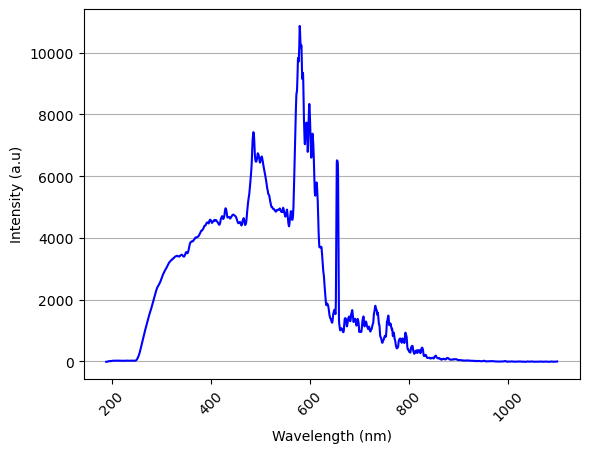

In [215]:
# move to the second alignment point by code: 50mm equals to 10000 distance
# 0&1 is used for direction
# go to point 1
ax = MoveAndMonitor('Alignment point 1',-10000/5,Spectrometer,5,0.9,500000,True,10,True,True,'blue',0,0,0,0,240,290,600,650,800,850)

#!!!!!go back to point 0 to start scan
    #ax = MoveAndMonitor('Alignment point 0',1,12000,Spectrometer,5,0.9,200000,True,10,True,True,'blue',0,0,0,0,240,290,600,650,800,850)

In [162]:
repeat = False
while repeat == True: 
    ax1 = MoveAndMonitor('Alignment point 1',-12000,Spectrometer,5,0.9,100000,True,10,True,True,'blue',0,0,0,0,240,290,600,650,800,850)
    time.sleep(5)
    ax2 = MoveAndMonitor('Alignment point 0',12000,Spectrometer,5,0.9,100000,True,10,True,True,'blue',0,0,0,0,240,290,600,650,800,850)
    time.sleep(5)

## locate droplet wells

In [17]:
def MultipleMonitor(direction,spec,recordtimelength,recordstep,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2):
    data_list= []
  
    if direction == 0:
        TruePosition_list = [1,3,5,7,9,11] 
        TrueDistance_list = [-10000/5,-10000/5,-10000/5,-10000/5,-10000/5,-10900/5]
    else:
        TruePosition_list = [10,8,6,4,2,0]
        TrueDistance_list = [10000/5,10000/5,10000/5,10000/5,10000/5,10900/5]
    for i,distance in zip(TruePosition_list,TrueDistance_list): 
        position = f'position{i}'
        data = MoveAndMonitor(position,distance,spec,recordtimelength,recordstep,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2)
        data_list.append({'Position': position, #create 3 data lists
                          'data':data[0],
                         'UVabs':data[1],
                        'Visabs':data[2]})
        
        
    df = pd.DataFrame(data_list)    
        
  # 2*5 sub plots          
    num_rows = 5
    num_cols = 2
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 18))  # Adjust figsize as needed

    if direction == 1:
        reversed_axes = reversed(axes.flatten())
    else:
        reversed_axes = axes.flatten()

    for t, ax in enumerate(reversed_axes):
        data_x, data_y = df['data'][t]
        position = df['Position'][t]
        uv_abs = int(df['UVabs'][t])
        vis_abs = int(df['Visabs'][t])
    
        ax.plot(data_x, data_y)
        ax.set_title(f' {position}\nUVabs = {uv_abs}, Visabs = {vis_abs}')
        ax.set_xlabel('X-axis label')  # Set appropriate labels
        ax.set_ylabel('Y-axis label')
        ax.grid(True)  # Add grid for better readability

    plt.tight_layout()  # Adjust subplot spacing automatically
    plt.show()

In [18]:
MultipleMonitor(0,Spectrometer,0.5,0.2,100000,True,10,True,True,'blue',0,0,0,0,240,290,600,650,0,0)

Motor 1 distance set to -2000.0 unit
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving
Moving


KeyboardInterrupt: 

# save data

In [10]:
def SpectroSavingAndMonitoring (foldername,position,spec,start_time,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2, base_path,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2):
    '''
    foldername = where this batch of data will be saved
    position = position of the well recording now
    spec = spectrometer object from seabreeze
    start_time = timepoint when measurement loop start
    OnceRecordLength = int / timewinbdow for once record
    integration = int / time to integrate for each spectra in micro seconds
    smoothbool = Bool whether to smoothen spectra or not 
    smoothfactor = int / width of box filter (x axis) --> 20 = high value
    darkcounts  = Bool - Whether to add darkcounts per spectra
    nonlinearity = Bool - whether to correct nonlinearity per spectra
    color = str / color of spectra
    x/ylim1/2 = int / stndrd mpl lims
    base_path = string containing the directory that contains the experiments directory'''
    
    ### ---- Initialise the function variables
    count = 0
    initialtime = time.perf_counter() ## initial time at start
    stoploop = True   # start the while loop
    #totaltime = OnceRecordLength  ## time you want the while loop to run in seconds
    spec.integration_time_micros(integration) ## set integration time
    wavelengths, intensities = spec.spectrum(correct_dark_counts=darkcounts, correct_nonlinearity=nonlinearity)
    spectra = np.vstack((wavelengths, intensities))
    abs1 = normalizeAndReduce(wavelengths, intensities, lower_bin=(UVbin1, UVbin2), 
                                           upper_bin=(Refbin1,Refbin2))
    abs2 = normalizeAndReduce(wavelengths, intensities, lower_bin=(Visbin1, Visbin2), 
                                           upper_bin=(Refbin1,Refbin2))
        ### check the time and then compare this to time to run for
    t = time.perf_counter()
    elapsed_time = t - initialtime
    recorded_time = t - start_time
    print(position,'saving UVabs =',int(abs1),'saving Visabs =',int(abs2),'at ',int(recorded_time),'s, Shottime =',int(elapsed_time),'s')
        ### --- Initialise directories for each position 

    data_end = plotting_spectra(wavelengths, intensities, smoothbool, smoothfactor, color,xlim1,xlim2,ylim1,ylim2)
         ###save to folder x 
    if foldername != 'NO save':
        dirname = os.path.join(base_path, foldername,position)
        Path(dirname).mkdir(parents=True, exist_ok=True)
        file = f"{foldername}_{position}_{datetime.now().strftime('%H:%M:%S')}.npy".replace(":","_") ### generates a string with the current time used as a unique embedding
        filename = os.path.join(dirname,file)
        np.save(filename, spectra)
    return data_end, abs1,abs2
      

In [11]:
def MoveAndSave(foldername,position,distance,spec,start_time,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2, base_path,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2):
    Moving = True
    motor1.setDistance(distance)
    
    n = 0 #position counter
    while Moving == True:
        a = motor1.ReadOutput()
        print(a)
        if 'In Position' in a:# motor stopped
            Moving = False
            time.sleep(0.1)#extend wait time to stop shaking
            save_data_end,save_abs1_end,save_abs2_end = SpectroSavingAndMonitoring (foldername,position,spec,start_time,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2, base_path,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2)
            display.clear_output(wait=True)
            time.sleep(1.1)# wait before moving again let the data collection of spectrum finish !!! the record time length must be smaller tham the sleep time here 
            return save_data_end,save_abs1_end,save_abs2_end
        else:
            print('Moving')
            display.clear_output(wait=True)

In [12]:
def MultipleSave(foldername,direction,spec,start_time,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,base_path,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2):
    start_time
    data_list= []

    #Distance_list1=[-1000/5,-10000/5,-10000/5,-10000/5,-10000/5,-10700/5]
    Distance_list1=[-9950/5,-10000/5,-10000/5,-10000/5,-10000/5,-10700/5]
    #Distance_list2=[10000/5,10000/5,10000/5,10000/5,10000/5,10450/5]
    Distance_list2=[9950/5,10000/5,10000/5,10000/5,10000/5,10700/5]


    #Distance_list1=[-60800/5]
    #Distance_list2=[60800/5]
    
 
    if direction == 0:
        TruePosition_list = [1,3,5,7,9,11] 
        TrueDistance_list = Distance_list1
    else:
        TruePosition_list = [10,8,6,4,2,0]
        TrueDistance_list = Distance_list2
    for i,distance in zip(TruePosition_list,TrueDistance_list): 
        position = f'position{i}'
        data = MoveAndSave(foldername,position,distance,spec,start_time,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,base_path,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2)
        data_list.append({'Position': position, 
                          'data':data[0],
                         'UVabs':data[1],
                         'Visabs':data[2]
                         })
        
        
    df = pd.DataFrame(data_list)   
        
            
  # 2*5 sub plots          
    '''
    num_rows = 5
    num_cols = 2
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 18))  # Adjust figsize as needed

    if direction == 1:
        reversed_axes = reversed(axes.flatten())
    else:
        reversed_axes = axes.flatten()

    for t, ax in enumerate(reversed_axes):
        data_x, data_y = df['data'][t]
        position = df['Position'][t]
        uv_abs = int(df['UVabs'][t])
        vis_abs = int(df['Visabs'][t])
    
        ax.plot(data_x, data_y)
        ax.set_title(f' {position}\nUVabs = {uv_abs}, Visabs = {vis_abs}')
        ax.set_xlabel('X-axis label')  # Set appropriate labels
        ax.set_ylabel('Y-axis label')
        ax.grid(True)  # Add grid for better readability

    plt.tight_layout()  # Adjust subplot spacing automatically
    plt.show()'''

In [13]:
def MultipleSaveLoop(totalrecordtime,spec,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,base_path,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2):
    # 240 s a loop
    LoopCount =0
    Foldername = input('Foldername')
    start_time = time.perf_counter() ## initial time at start
    stoploop = True   # start the while loop
    totalrecordtime=totalrecordtime ## time you want the while loop to run in seconds
    while stoploop == True:
        
        MultipleSave(Foldername,0,spec,start_time,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,base_path,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2)
        #time.sleep(0.5)
        MultipleSave(Foldername,1,spec,start_time,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,base_path,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2) 
        #time.sleep(0.5)
        LoopCount +=1
        t = time.perf_counter()
        Recorded_time = t - start_time
        if Recorded_time > totalrecordtime:  ## check if the amount of time has elapased and turn off the while loop, ending the process
            stoploop = False
            return LoopCount


In [26]:
Monitor_1 = monitorfunction('Alignment point 1',Spectrometer,600,0.9,150000,True,10,True,True,'blue',0,0,0,0,250,290,600,650,0,0)

Alignment point 1 monitoring UV abs = 3216 Vis abs = 15643 shottime = 27 s


KeyboardInterrupt: 

# New Laptop

In [27]:
MultipleSaveLoop(900,Spectrometer,150000,True,10,True,True,'blue',0,0,0,0,r'C:\data\syngenta agrochemicals',250,290,600,650,0,0)

28

In [18]:
ax = MoveAndMonitor('Alignment point 0',0,12020,Spectrometer,5,0.9,100000,True,10,True,True,'blue',0,0,0,0,240,290,600,650,0,0)

NameError: name 'MoveAndMonitor' is not defined